In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df=pd.read_csv('Indian_Kids_Screen_Time.csv')

In [3]:
# Display the first 5 rows of the dataset
df.head(5)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [4]:
# Display the last 5 rows of the dataset
df.tail()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban
9711,15,Female,6.12,TV,True,0.33,Anxiety,Urban


In [5]:
# Display the summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [12]:
# Display the statistical summary of the dataset
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [5]:
#fill the missing values in the 'Health_Impacts' column with the mode of the column
df['Health_Impacts']= df['Health_Impacts'].fillna(df['Health_Impacts'].mode()[0])

In [7]:
#after filling the missing values, check for any remaining null values
df.isnull().sum()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     9712 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [16]:
# Create a new column 'Age_Band' based on the 'Age' column
df['Age_Band']= pd.cut(df['Age'], bins=[0, 5, 9, 13, 17], labels=['3-5', '6-9', '10-13', '14-17'])
df.sample(5)


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Screen_time_level
6056,9,Female,7.83,TV,True,0.49,"Poor Sleep, Eye Strain",Urban,6-9,Very high
891,12,Male,4.44,TV,True,0.35,Eye Strain,Urban,10-13,High
7966,12,Female,5.66,Smartphone,True,0.31,Eye Strain,Rural,10-13,High
6158,9,Female,8.08,Smartphone,True,0.50,Poor Sleep,Rural,6-9,Very high
6951,13,Female,4.46,Tablet,True,0.34,"Poor Sleep, Eye Strain",Rural,10-13,High


In [17]:
# check any null values in the 'Age_Band' column
df.isnull().sum()

Age                                    0
Gender                                 0
Avg_Daily_Screen_Time_hr               0
Primary_Device                         0
Exceeded_Recommended_Limit             0
Educational_to_Recreational_Ratio      0
Health_Impacts                         0
Urban_or_Rural                         0
Age_Band                             840
Screen_time_level                    226
dtype: int64

In [19]:
# fill the missing values in the Age_Band column with the mode of the column
df['Age_Band'].fillna(df['Age_Band'].mode()[0], inplace=True)

# after filling the missing values, check for any remaining null values 
df.isnull().sum()

Age                                    0
Gender                                 0
Avg_Daily_Screen_Time_hr               0
Primary_Device                         0
Exceeded_Recommended_Limit             0
Educational_to_Recreational_Ratio      0
Health_Impacts                         0
Urban_or_Rural                         0
Age_Band                               0
Screen_time_level                    226
dtype: int64

In [6]:
# Create a new column 'Screen_time_level' based on the 'Avg_Daily_Screen_Time_hr' column
df['Screen_time_level']=pd.cut(df['Avg_Daily_Screen_Time_hr'], bins=[0,2,4,6,24], labels=['Low', 'Moderate', 'High', 'Very high'])
df.sample(5)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Screen_time_level
3884,18,Male,4.36,TV,True,0.47,Poor Sleep,Urban,NaN,High
7530,16,Female,1.86,Tablet,False,0.45,Poor Sleep,Urban,14-17,Low
5187,12,Male,4.69,Tablet,True,0.50,Poor Sleep,Urban,10-13,High
6607,11,Female,3.92,Laptop,True,0.40,Eye Strain,Rural,10-13,Moderate
5841,8,Female,2.15,TV,True,0.60,Poor Sleep,Rural,6-9,Moderate


In [20]:
# check the any missing values in the 'Screen_time_level' column
df.isnull().sum()

Age                                    0
Gender                                 0
Avg_Daily_Screen_Time_hr               0
Primary_Device                         0
Exceeded_Recommended_Limit             0
Educational_to_Recreational_Ratio      0
Health_Impacts                         0
Urban_or_Rural                         0
Age_Band                               0
Screen_time_level                    226
dtype: int64

In [21]:
# fill the missing values in the Screen_time_level column with the mode of the column
df['Screen_time_level'].fillna(df['Screen_time_level'].mode()[0], inplace=True)

# after filling the missing values, check for any remaining null values
df.isnull().sum()

Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
Age_Band                             0
Screen_time_level                    0
dtype: int64

<Axes: xlabel='Avg_Daily_Screen_Time_hr', ylabel='Count'>

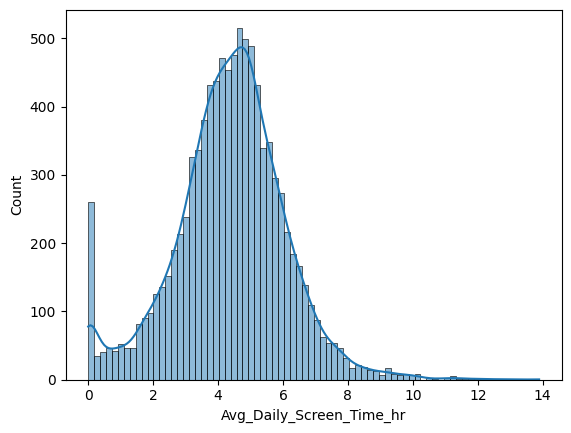

In [13]:
sns.histplot(df['Avg_Daily_Screen_Time_hr'], kde=True)

Most children spend between 2–4 hours daily, with a small segment exceeding 6 hours.

Text(0.5, 1.0, 'Screen time level distribution')

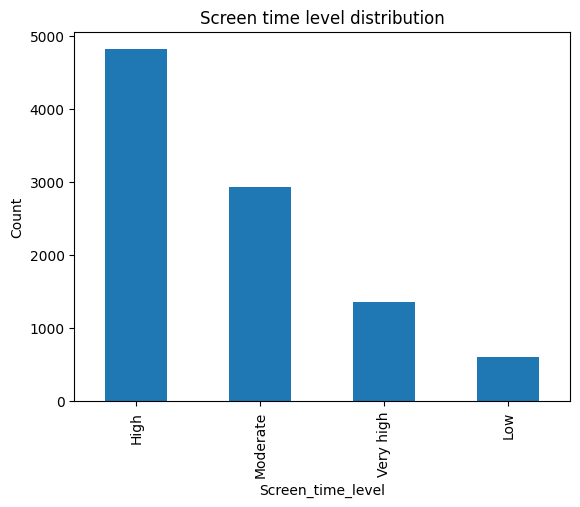

In [22]:
# To visualize the distribution of screen time levels among the children,
#  we can create a bar plot showing the count of each screen time level category.

df['Screen_time_level'].value_counts().plot(kind='bar')
plt.xlabel('Screen_time_level')
plt.ylabel('Count')
plt.title('Screen time level distribution')

# There is a significant number of children in the 'High' screen time level, 
# which indicates that many children are spending a lot of time in front of screens. 
# This could have potential health implications and may require attention from parents and caregivers to 
# ensure a healthy balance between screen time and other activities.

<Axes: xlabel='Primary_Device'>

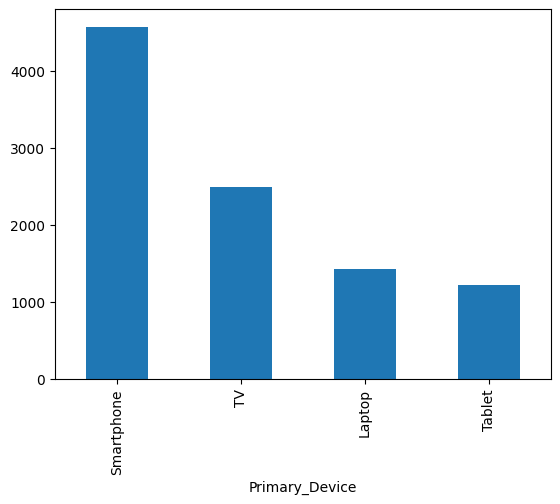

In [30]:
# to check the device usage distribution . 
# our goal is to understand which devices are most commonly used by children for screen time,

#sns.barplot(x=df['Primary_Device'].value_counts().index, y=df['Age_Band'].value_counts().values, palette='viridis')

df['Primary_Device'].value_counts().plot(kind='bar',style='viridis')

# Here we can see that the most commonly used device for screen time among children is the 'Smartphone'.

<Axes: ylabel='count'>

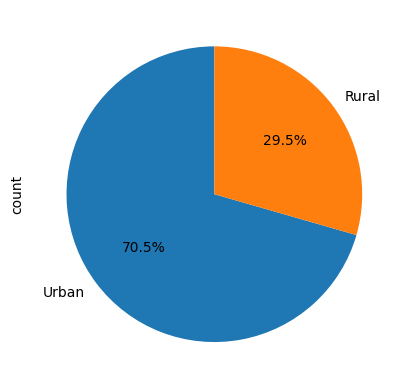

In [23]:
# To check Urban vs Rural which had more dominance
df['Urban_or_Rural'].value_counts().plot(kind='pie', color='orange', autopct='%1.1f%%', startangle=90)

# I saw that the urban children had more screen time than rural children. To further investigate this, 
# I can create a bar plot to compare the average daily screen time between urban and rural children.

<Axes: xlabel='Urban_or_Rural'>

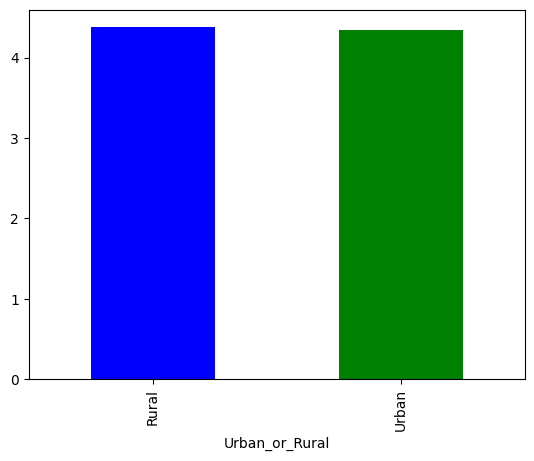

In [40]:
df['Avg_Daily_Screen_Time_hr'].groupby(df['Urban_or_Rural']).mean().plot(kind='bar', color=['blue', 'green'])

<Axes: xlabel='Age_Band', ylabel='Avg_Daily_Screen_Time_hr'>

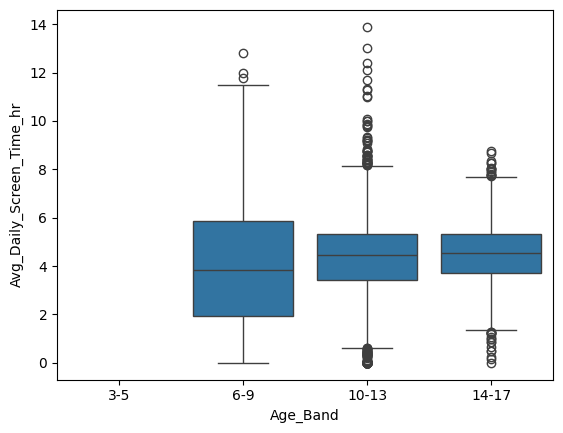

In [24]:
# Create a boxplot to visualize the distribution of 'Avg_Daily_Screen_Time_hr' across different 'Age_Band'
sns.boxplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=df)

# here we can see that the median screen time is highest for the age band 14-17, followed by 10-13, 6-9, and lowest for 3-5. 
# This suggests that older children tend to have higher screen time compared to younger children.

C:\Users\HP\AppData\Local\Temp\ipykernel_4228\1719040608.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df, palette='Set2')


<Axes: xlabel='Gender', ylabel='Avg_Daily_Screen_Time_hr'>

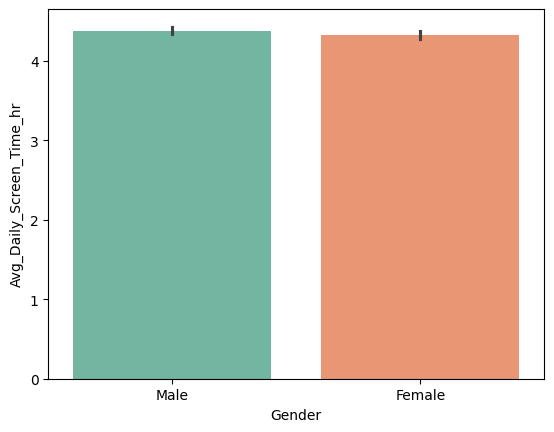

In [43]:
#  compare gender-wise screen time distribution using a boxplot
sns.barplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df, palette='Set2')

# here we saw that the male children had more screen time than the female children on average

<Axes: xlabel='Age_Band', ylabel='count'>

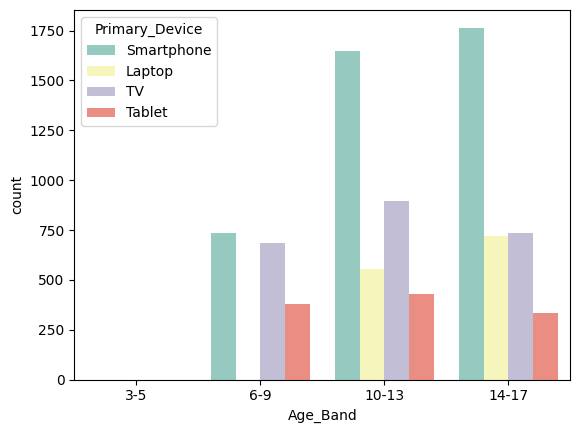

In [44]:
# Age Band  vs Device Type
sns.countplot(x='Age_Band', hue='Primary_Device', data=df, palette='Set3')

# Here we saw that the smartphone is the most commonly used device across all age bands, with the highest usage in the 14-17 age band. T
# Tablets and laptops are less commonly used, with tablets being more popular among younger children (3-5 age band) and laptops being more popular among older children (10-13 and 14-17 age bands).

In [25]:
# Cohort Analysis: To analyze the average daily screen time across different age bands and primary devices 
cohort = pd.pivot_table(
    df,
    index='Age_Band',
    columns='Primary_Device',
    values='Avg_Daily_Screen_Time_hr',
    aggfunc='mean'
)
cohort

Primary_Device,Laptop,Smartphone,TV,Tablet
Age_Band,,,,
6-9,NaN,3.891583,4.014378,3.998766
10-13,4.432627,4.423919,4.251453,4.176112
14-17,4.475664,4.529150,4.528900,4.485337


<Axes: xlabel='Primary_Device', ylabel='Age_Band'>

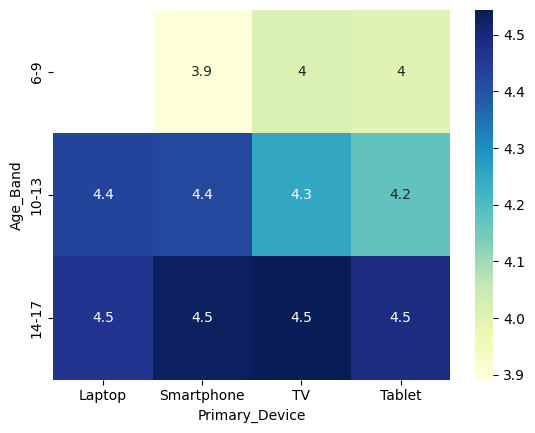

In [16]:
sns.heatmap(cohort, annot=True, cmap='YlGnBu')

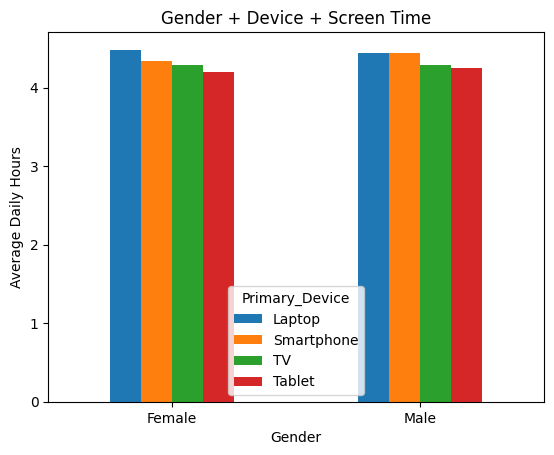

In [10]:
 # 2️⃣ Gender + Device + Screen Time (Grouped Bar Chart)
gender_device = pd.pivot_table(df,
                               values='Avg_Daily_Screen_Time_hr',
                               index='Gender',
                               columns='Primary_Device',
                               aggfunc='mean')

# chart
gender_device.plot(kind='bar')

plt.title("Gender + Device + Screen Time")
plt.ylabel("Average Daily Hours")
plt.xticks(rotation=0)
plt.show()


# Observation of above Image.
The chart shows that average screen time is very similar for both males and females across all devices.
Laptop and smartphone usage have slightly higher screen time compared to TV and tablet for both genders.
Overall, gender does not show a significant difference in screen time patterns across devices.

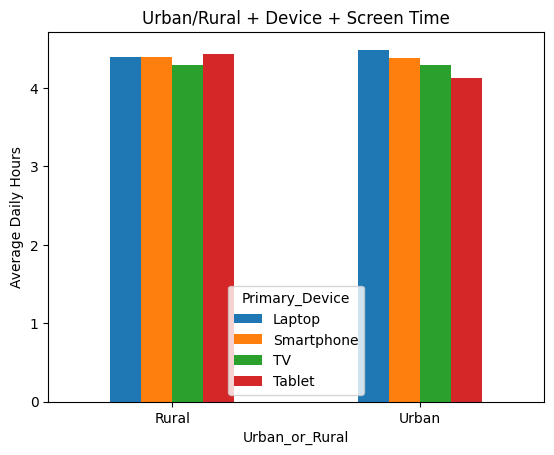

In [ ]:
# 3️⃣ Urban/Rural + Device + Screen Time (Grouped Bar)

location_device = pd.pivot_table(df,
                                 values='Avg_Daily_Screen_Time_hr',
                                 index='Urban_or_Rural',
                                 columns='Primary_Device',
                                 aggfunc='mean')

# chart
location_device.plot(kind='bar')

plt.title("Urban/Rural + Device + Screen Time")
plt.ylabel("Average Daily Hours")
plt.xticks(rotation=0)
plt.show()

# Obs. of above image
Screen time is similar in both urban and rural areas across most devices. Urban children use laptops slightly more, while rural children use tablets and smartphones slightly more.

<Axes: xlabel='Primary_Device', ylabel='Avg_Daily_Screen_Time_hr'>

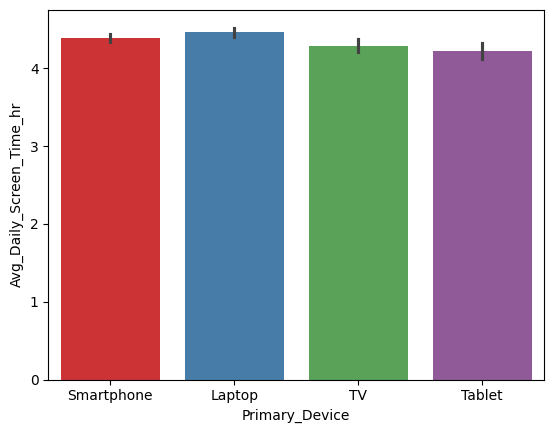

In [8]:
# screen time by primary device
sns.barplot(x='Primary_Device', y='Avg_Daily_Screen_Time_hr', data=df, palette='Set1')

# here we saw that the avg daily screen time is highest for laptops

<Axes: xlabel='Primary_Device', ylabel='Avg_Daily_Screen_Time_hr'>

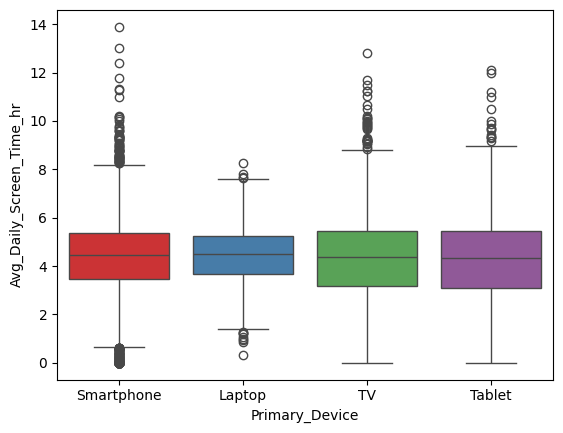

In [9]:
sns.boxplot(x='Primary_Device', y='Avg_Daily_Screen_Time_hr', data=df, palette='Set1')

# Obs. of above image
The distribution of daily screen time is similar across devices, with median usage around 4–5 hours. Smartphones and tablets show greater variability and more high-usage outliers, suggesting that excessive screen time is slightly more common on these devices. However, high usage is observed across all device types.

In [11]:
# Define recommendations level 

recommended_limit = 2

df['Exceeds_Limit'] = df['Avg_Daily_Screen_Time_hr'] > recommended_limit


In [14]:
#Calculate % True per Device

risk_table = pd.pivot_table(df,
                            values='Exceeds_Limit',
                            index='Primary_Device',
                            aggfunc='mean')

In [17]:
# Now convert the mean values to percentages
risk_table['Risk_Percentage'] = risk_table['Exceeds_Limit'] * 100

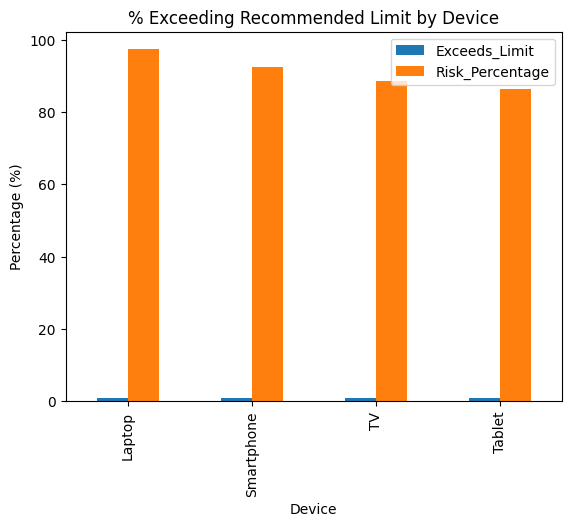

In [23]:
# Ranked bar chart of risk percentages by device

risk_table.plot(kind='bar')

plt.title("% Exceeding Recommended Limit by Device")
plt.xlabel("Device")
plt.ylabel("Percentage (%)")
plt.show()

In [21]:
highest_risk_device = risk_table.idxmax()
highest_risk_value = risk_table.max()

print("Highest Risk Device:", highest_risk_device)
print("Risk Percentage:", round(highest_risk_value,2), "%")

Highest Risk Device: Exceeds_Limit      Laptop
Risk_Percentage    Laptop
dtype: object
Risk Percentage: Exceeds_Limit       0.97
Risk_Percentage    97.35
dtype: float64 %


# We saw that the highest risk device is Laptop with 97% .

In [ ]:
# Save the processed dataset to a new CSV file
df.to_csv( 'Indian_Kids_Screen_Time_Processed.csv', index=False)